In [25]:
import vtuIO
import matplotlib.pyplot as plt
import os
from pathlib import Path

os.chdir(Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out")))

In [26]:
import Mesh_settings

ey = Mesh_settings.ey

if ey == 1: #2D
    dim = 2
    ax = 1
else:       #3D
    dim = 3
    ax = 2

pvdfile = vtuIO.PVDIO("uplift.pvd", dim=dim, interpolation_backend="scipy")
time = pvdfile.timesteps

points = {"pt0": (0, 0,0), "pt1": (0, 0,-30),"pt2": (0, 0,-50)}

Here we plot the time series.

In [27]:
displacement_linear = pvdfile.read_time_series("displacement", points)
#displacement_nearest = pvdfile.read_time_series("displacement", points, interpolation_method="nearest")

Here we plot the graphs.

Text(0, 0.5, 'Displacement (m)')

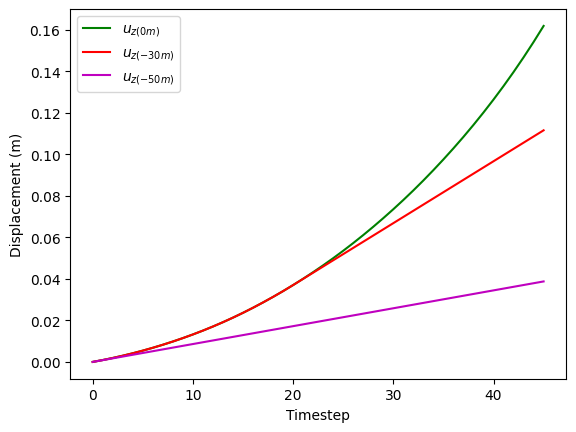

In [28]:
plt.plot(time, displacement_linear["pt0"][:,ax], "g-", label="$u_{z(" + str(points["pt0"][ax]) + "m)}$")
plt.plot(time, displacement_linear["pt1"][:,ax], "r-", label="$u_{z(" + str(points["pt1"][ax]) + "m)}$")
plt.plot(time, displacement_linear["pt2"][:,ax], "m-", label="$u_{z(" + str(points["pt2"][ax]) + "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("Displacement (m)")
#plt.xscale('log')

In [29]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(0, 0.5, '$\\Delta$u$_{y}$ (m)')

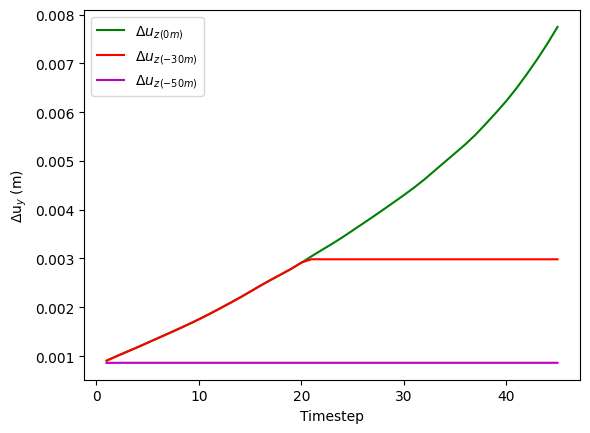

In [30]:
relative_pt0_displacement =displacement_linear["pt0"][1:, ax]-displacement_linear["pt0"][:-1, ax]
plt.plot(time[1:], relative_pt0_displacement , "g-",  label='$\Delta$$u$$_z$$_{('+ str(points["pt0"][ax])+ 'm)}$')

relative_pt1_displacement =displacement_linear["pt1"][1:, ax]-displacement_linear["pt1"][:-1, ax]
plt.plot(time[1:], relative_pt1_displacement , "r-",  label='$\Delta$$u$$_z$$_{('+ str(points["pt1"][ax])+ 'm)}$')

relative_pt2_displacement = displacement_linear["pt2"][1:, ax]-displacement_linear["pt2"][:-1, ax]
plt.plot(time[1:], relative_pt2_displacement , "m-", label='$\Delta$$u$$_z$$_{('+ str(points["pt2"][ax])+ 'm)}$')


plt.legend()
plt.xlabel("Timestep")
plt.ylabel("$\Delta$u$_{y}$" + " (m)")

In [31]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(-10, 0.16194023696868795, '0.162')

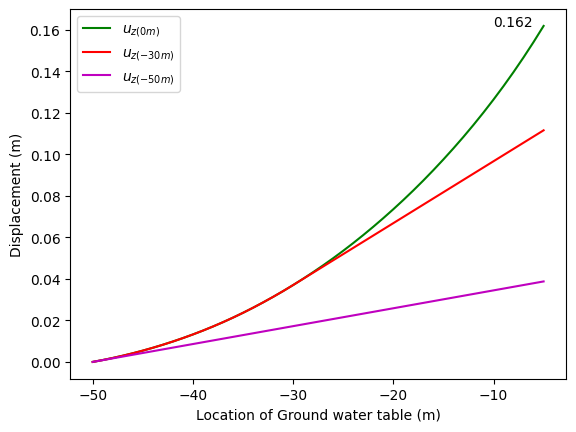

In [32]:
GWT = -50 + time * 1

plt.plot(GWT, displacement_linear["pt0"][:, ax], "g-",  label="$u_{z(" + str(points["pt0"][ax]) + "m)}$")
plt.plot(GWT, displacement_linear["pt1"][:, ax], "r-", label="$u_{z(" + str(points["pt1"][ax]) + "m)}$")
plt.plot(GWT, displacement_linear["pt2"][:, ax], "m-", label="$u_{z(" + str(points["pt2"][ax]) + "m)}$")

plt.legend()
plt.xlabel("Location of Ground water table (m)")
plt.ylabel("Displacement (m)")
last_data= displacement_linear["pt0"][-1, ax]
last_data_3decimal= "%.3f" % round(last_data, 3)
plt.annotate(str(last_data_3decimal),(-10, last_data))

In [33]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(0, 0.5, "$\\sigma'_{yy}$ (Pa)")

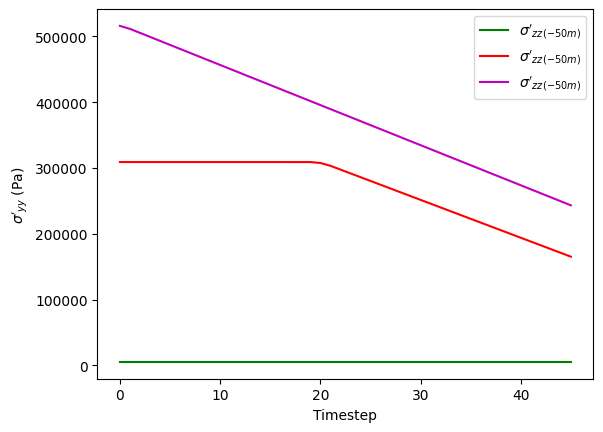

In [34]:
stress = pvdfile.read_time_series("sigma", points, interpolation_method="linear")
plt.plot(time, -stress["pt0"][:, ax], "g-",  label="$\sigma\'_{zz}$$_{("+ str(points["pt2"][ax])+ "m)}$")
plt.plot(time, -stress["pt1"][:, ax], "r-", label="$\sigma\'_{zz}$$_{("+ str(points["pt2"][ax])+ "m)}$")
plt.plot(time, -stress["pt2"][:, ax], "m-", label="$\sigma\'_{zz}$$_{("+ str(points["pt2"][ax])+ "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("$\sigma\'_{yy}$" + " (Pa)")

In [35]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(0, 0.5, "$\\Delta\\sigma'_{zz}$ (Pa)")

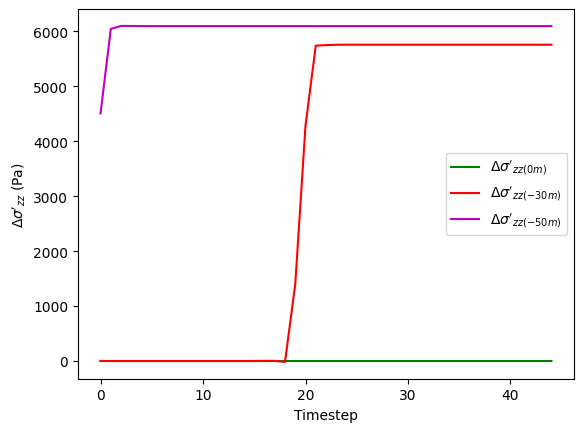

In [36]:
stress = pvdfile.read_time_series("sigma", points, interpolation_method="linear")

relative_pt0_stress = stress["pt0"][1:, ax]-stress["pt0"][:-1, ax]
plt.plot(time[:-1], relative_pt0_stress, "g-",  label="$\Delta\sigma\'_{zz}$$_{("+ str(points["pt0"][ax])+ "m)}$")

relative_pt1_stress = stress["pt1"][1:, ax]-stress["pt1"][:-1, ax]
plt.plot(time[:-1], relative_pt1_stress, "r-",  label="$\Delta\sigma\'_{zz}$$_{("+ str(points["pt1"][ax])+ "m)}$")

relative_pt2_stress = stress["pt2"][1:, ax]-stress["pt2"][:-1, ax]
plt.plot(time[:-1], relative_pt2_stress, "m-", label="$\Delta\sigma\'_{zz}$$_{("+ str(points["pt2"][ax])+ "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("$\Delta\sigma\'_{zz}$" + " (Pa)")

In [37]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(0, 0.5, 'Epsilon')

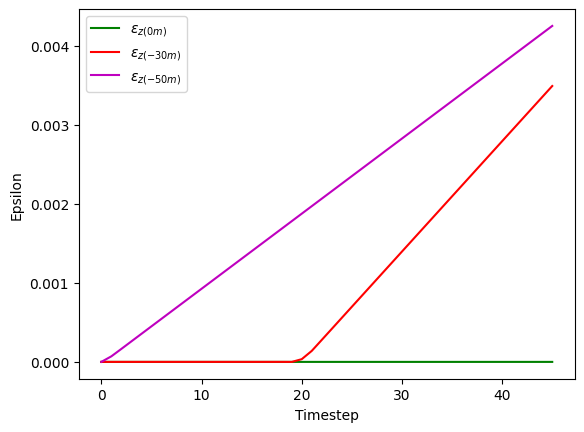

In [38]:
epsilon = pvdfile.read_time_series("epsilon", points, interpolation_method="linear")
plt.plot(time, epsilon ["pt0"][:, 2], "g-", label="$\epsilon_{z("+ str(points["pt0"][ax]) + "m)}$")
plt.plot(time, epsilon ["pt1"][:, 2], "r-", label="$\epsilon_{z("+ str(points["pt1"][ax]) + "m)}$")
plt.plot(time, epsilon ["pt2"][:, 2], "m-", label="$\epsilon_{z("+ str(points["pt2"][ax]) + "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("Epsilon")

In [39]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(0, 0.5, 'Change in Epsilon')

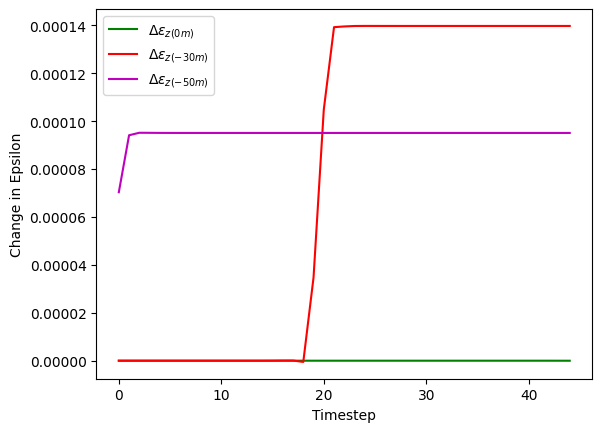

In [40]:
relative_pt0_epsilon = epsilon ["pt0"][1:, ax] - epsilon ["pt0"][:-1, ax]
relative_pt1_epsilon = epsilon ["pt1"][1:, ax] - epsilon ["pt1"][:-1, ax]
relative_pt2_epsilon = epsilon ["pt2"][1:, ax] - epsilon ["pt2"][:-1, ax]


plt.plot(time[:-1], relative_pt0_epsilon, "g-", label="$\Delta\epsilon_{z("+ str(points["pt0"][ax]) + "m)}$")
plt.plot(time[:-1], relative_pt1_epsilon, "r-", label="$\Delta\epsilon_{z("+ str(points["pt1"][ax]) + "m)}$")
plt.plot(time[:-1], relative_pt2_epsilon, "m-", label="$\Delta\epsilon_{z("+ str(points["pt2"][ax]) + "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("Change in Epsilon")

In [41]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(0, 0.5, 'Pore pressure (Pa)')

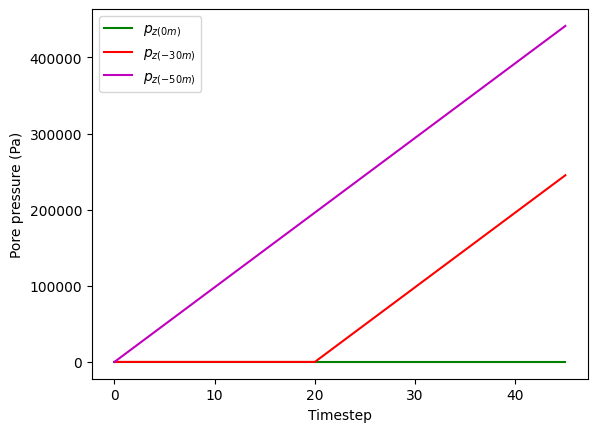

In [42]:
pore_pressure = pvdfile.read_time_series("pressure", points, interpolation_method="linear")
plt.plot(time, pore_pressure ["pt0"], "g-", label="$p_{z("+ str(points["pt0"][ax]) + "m)}$")
plt.plot(time, pore_pressure ["pt1"], "r-", label="$p_{z(" + str(points["pt1"][ax]) + "m)}$")
plt.plot(time, pore_pressure ["pt2"], "m-", label="$p_{z("+ str(points["pt2"][ax]) + "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("Pore pressure (Pa)")

Text(0, 0.5, 'Change in pore pressure (Pa)')

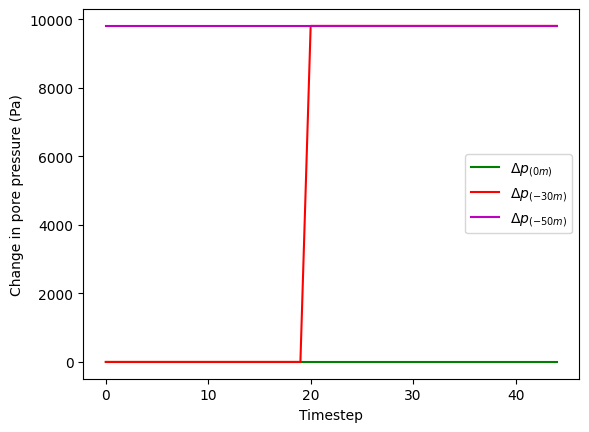

In [43]:
relative_pt0_pore_pressure = pore_pressure ["pt0"][1:] - pore_pressure ["pt0"][:-1]
relative_pt1_pore_pressure = pore_pressure ["pt1"][1:] - pore_pressure ["pt1"][:-1]
relative_pt2_pore_pressure = pore_pressure ["pt2"][1:] - pore_pressure ["pt2"][:-1]

plt.plot(time[:-1], relative_pt0_pore_pressure , "g-", label="$\Delta p_{("+ str(points["pt0"][ax]) + "m)}$")
plt.plot(time[:-1], relative_pt1_pore_pressure , "r-", label="$\Delta p_{("+ str(points["pt1"][ax]) + "m)}$")
plt.plot(time[:-1], relative_pt2_pore_pressure , "m-", label="$\Delta p_{("+ str(points["pt2"][ax]) + "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("Change in pore pressure (Pa)")

Text(0, 0.5, '$\\sigma$$_{zz}$ (Pa)')

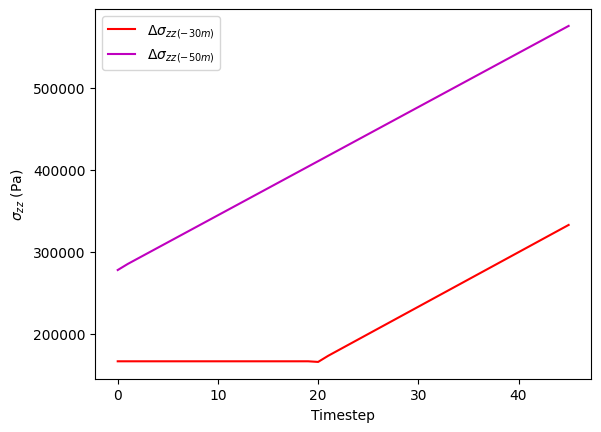

In [44]:
totalstress_pt0 = -stress["pt0"][:, 1] + pore_pressure["pt0"]
totalstress_pt1 = -stress["pt1"][:, 1] + pore_pressure["pt1"]
totalstress_pt2 = -stress["pt2"][:, 1] + pore_pressure["pt2"]

#plt.plot(time, totalstress_pt0 , "g-", label="$totalstress_{zz("+ str(points["pt0"][1]) + "m)}$")
plt.plot(time, totalstress_pt1 , "r-", label='$\Delta\sigma$$_{zz}$$_{('+ str(points["pt1"][ax])+ 'm)}$')
plt.plot(time, totalstress_pt2 , "m-", label='$\Delta\sigma$$_{zz}$$_{('+ str(points["pt2"][ax])+ 'm)}$')

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("$\sigma$$_{zz}$" + ' (Pa)')

In [45]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(0, 0.5, '$\\Delta$$\\sigma$$_{zz}$')

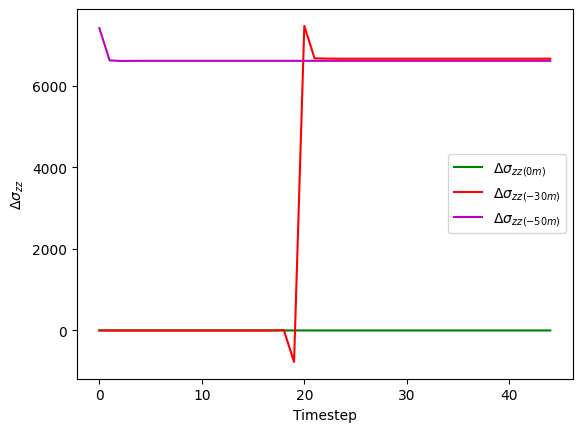

In [46]:
relative_pt0_totalstress = totalstress_pt0[1:] - totalstress_pt0[:-1]
relative_pt1_totalstress = totalstress_pt1[1:] - totalstress_pt1[:-1]
relative_pt2_totalstress = totalstress_pt2[1:] - totalstress_pt2[:-1]

plt.plot(time[:-1], relative_pt0_totalstress , "g-", label="$\Delta\sigma_{zz}$$_{("+ str(points["pt0"][ax])+ "m)}$")
plt.plot(time[:-1], relative_pt1_totalstress , "r-", label="$\Delta\sigma_{zz}$$_{("+ str(points["pt1"][ax])+ "m)}$")
plt.plot(time[:-1], relative_pt2_totalstress , "m-", label="$\Delta\sigma_{zz}$$_{("+ str(points["pt2"][ax])+ "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("$\Delta$$\sigma$$_{zz}$")

In [47]:
os.chdir('..')